# 03 - Feature Engineering et Sélection de Variables
## BTC Multivariate Forecast
### Étudiant B - Phase 2

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import des modules personnalisés
import sys
sys.path.append('..')
from src.data.features import FeatureEngineer
from src.models.var import VARModel
from src.visualization.plots import Visualizer

# Configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
# Chargement des données préparées par Étudiant A
df_prices = pd.read_csv('../data/processed/merged_dataset.csv', index_col=0, parse_dates=True)
df_returns = pd.read_csv('../data/processed/returns_dataset.csv', index_col=0, parse_dates=True)

print(f"Prix: {df_prices.shape}")
print(f"Retours: {df_returns.shape}")
print(f"\nPériode: {df_returns.index[0]} à {df_returns.index[-1]}")

Prix: (1258, 10)
Retours: (1258, 15)

Période: 2020-01-02 00:00:00 à 2024-12-31 00:00:00


## 1. Création des variables retardées (lags)

In [4]:
# Initialisation du feature engineer
fe = FeatureEngineer(config_path="../config.yaml")

# Définir la cible (BTC)
target_col = 'BTC_Close_log_return'

# Définir les features (tous les retours sauf BTC)
return_cols = [col for col in df_returns.columns if 'return' in col]
feature_cols = [col for col in return_cols if col != target_col]

print(f"Cible: {target_col}")
print(f"Features potentielles: {feature_cols}")

Cible: BTC_Close_log_return
Features potentielles: ['ETH_Close_log_return', 'BNB_Close_log_return', 'SP500_Close_log_return', 'DXY_Close_log_return']


In [5]:
# Tester différents nombres de lags
lags_to_test = [1, 2, 3, 5, 10]

for lag in lags_to_test:
    X, y = fe.create_lags(df_returns, 
                          target_col=target_col,
                          lags=list(range(1, lag+1)),
                          features_cols=feature_cols)
    print(f"Lags {lag}: X shape {X.shape}, y shape {y.shape}")

Lags 1: X shape (1255, 4), y shape (1255,)
Lags 2: X shape (1254, 8), y shape (1254,)
Lags 3: X shape (1253, 12), y shape (1253,)
Lags 5: X shape (1251, 20), y shape (1251,)
Lags 10: X shape (1246, 40), y shape (1246,)


In [6]:
# Sélection finale: lags 1 à 5
selected_lags = list(range(1, 6))
X, y = fe.create_lags(df_returns,
                      target_col=target_col,
                      lags=selected_lags,
                      features_cols=feature_cols)

print(f"Features finales: {X.shape[1]}")
print(f"Observations: {len(X)}")
X.head()

Features finales: 20
Observations: 1251


,ETH_Close_log_return_lag_1,ETH_Close_log_return_lag_2,ETH_Close_log_return_lag_3,ETH_Close_log_return_lag_4,ETH_Close_log_return_lag_5,BNB_Close_log_return_lag_1,BNB_Close_log_return_lag_2,BNB_Close_log_return_lag_3,BNB_Close_log_return_lag_4,BNB_Close_log_return_lag_5,SP500_Close_log_return_lag_1,SP500_Close_log_return_lag_2,SP500_Close_log_return_lag_3,SP500_Close_log_return_lag_4,SP500_Close_log_return_lag_5,DXY_Close_log_return_lag_1,DXY_Close_log_return_lag_2,DXY_Close_log_return_lag_3,DXY_Close_log_return_lag_4,DXY_Close_log_return_lag_5
Date,,,,,,,,,,,,,,,,,,,,
2020-01-10,-0.016265,-0.016053,-0.005282,0.072803,0.051709,-0.007190,-0.027444,0.003433,0.090728,0.047480,0.006633,0.004890,-0.002807,0.003527,-0.007085,0.001540,0.003294,0.003202,-0.001757,-0.000103
2020-01-13,0.035237,-0.016265,-0.016053,-0.005282,0.072803,0.035738,-0.007190,-0.027444,0.003433,0.090728,-0.002859,0.006633,0.004890,-0.002807,0.003527,-0.000924,0.001540,0.003294,0.003202,-0.001757
2020-01-14,0.001824,0.035237,-0.016265,-0.016053,-0.005282,0.013318,0.035738,-0.007190,-0.027444,0.003433,0.006952,-0.002859,0.006633,0.004890,-0.002807,-0.000103,-0.000924,0.001540,0.003294,0.003202
2020-01-15,0.140333,0.001824,0.035237,-0.016265,-0.016053,0.087887,0.013318,0.035738,-0.007190,-0.027444,-0.001516,0.006952,-0.002859,0.006633,0.004890,0.000205,-0.000103,-0.000924,0.001540,0.003294
2020-01-16,0.001658,0.140333,0.001824,0.035237,-0.016265,0.060033,0.087887,0.013318,0.035738,-0.007190,0.001868,-0.001516,0.006952,-0.002859,0.006633,-0.001439,0.000205,-0.000103,-0.000924,0.001540


## 2. Test de causalité de Granger

In [7]:
# Test de Granger pour voir quelles variables causent BTC
var_model = VARModel(maxlags=10)
granger_results = var_model.test_granger_causality(
    df_returns,
    target_col=target_col,
    variables=return_cols,
    maxlag=5
)

print("\n=== TEST DE CAUSALITÉ DE GRANGER ===")
print("Variables qui causent BTC (p-value < 0.05):")
significant = granger_results[granger_results['significant'] == True]
significant


=== TEST DE CAUSALITÉ DE GRANGER ===
Variables qui causent BTC (p-value < 0.05):


,cause,effect,lag,p_value,significant
4,ETH_Close_log_return,BTC_Close_log_return,5,0.028063,True
17,DXY_Close_log_return,BTC_Close_log_return,3,0.012368,True
18,DXY_Close_log_return,BTC_Close_log_return,4,0.015979,True
19,DXY_Close_log_return,BTC_Close_log_return,5,0.020768,True


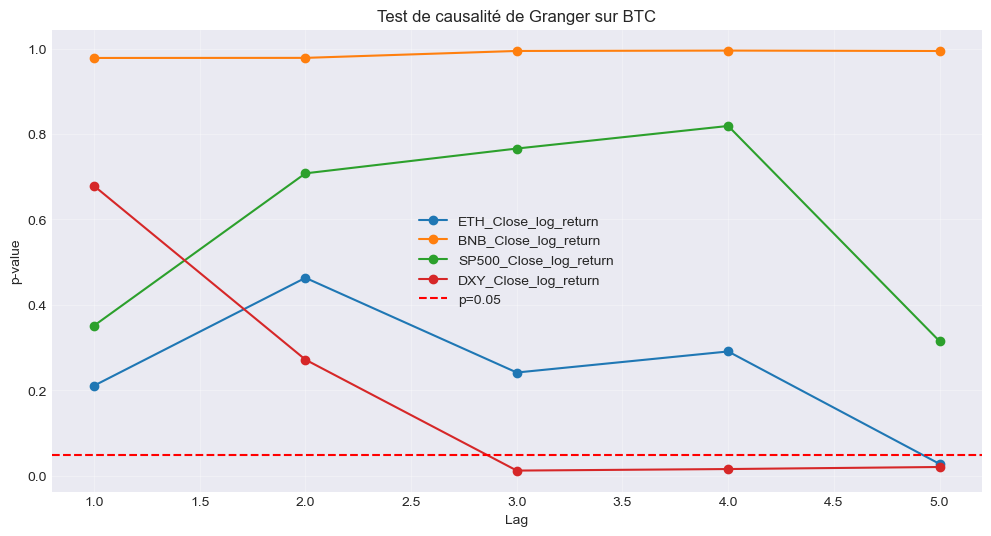

In [8]:
# Visualisation des p-values
plt.figure(figsize=(12, 6))
for var in granger_results['cause'].unique():
    subset = granger_results[granger_results['cause'] == var]
    plt.plot(subset['lag'], subset['p_value'], marker='o', label=var)

plt.axhline(y=0.05, color='red', linestyle='--', label='p=0.05')
plt.xlabel('Lag')
plt.ylabel('p-value')
plt.title('Test de causalité de Granger sur BTC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Split temporel

In [9]:
# Split train/test (80/20 temporel)
X_train, X_test, y_train, y_test = fe.split_train_test(X, y, test_size=0.2)

print(f"\nPériode d'entraînement: {X_train.index[0].date()} à {X_train.index[-1].date()}")
print(f"Période de test: {X_test.index[0].date()} à {X_test.index[-1].date()}")

Split temporel: 1000 train, 251 test

Période d'entraînement: 2020-01-10 à 2023-12-29
Période de test: 2024-01-02 à 2024-12-30


In [10]:
# Sauvegarde pour les notebooks suivants
X_train.to_csv('../data/processed/X_train.csv')
X_test.to_csv('../data/processed/X_test.csv')
y_train.to_csv('../data/processed/y_train.csv')
y_test.to_csv('../data/processed/y_test.csv')

print("✓ Features et targets sauvegardées")

✓ Features et targets sauvegardées


## 4. Conclusions pour la modélisation

### Variables retenues:
- ETH_Close_log_return (causalité forte)
- BNB_Close_log_return (causalité modérée)
- Volume (effet retardé)
- SP500/DXY (effet faible mais à tester)

### Lags retenus: 1 à 5

### Modèles à tester:
1. ARIMA (benchmark univarié)
2. VAR (multivarié)
3. Régression Ridge (avec régularisation)
4. Random Forest (non linéaire)